In [8]:
import pandas as pd
import numpy as np
from collections import defaultdict
import random
from tqdm import tqdm
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from seqeval.metrics import f1_score as span_f1_score
from sklearn.metrics import f1_score
import gensim.downloader as api

In [9]:
LabelToID = {
    'O': 0,
    'B-Date': 1,
    'I-Date': 2,
    'B-Person': 3,
    'I-Person': 4,
    'B-Location': 5,
    'I-Location': 6,
    'B-Facility': 7,
    'I-Facility': 8,
    'B-Organization': 9,
    'I-Organization': 10,
    'B-Misc': 11,
    'I-Misc': 12,
    'B-Money': 13,
    'I-Money': 14,
    'B-NORP': 15,
    'I-NORP': 16,
    'B-Product': 17,
    'I-Product': 18}

In [10]:
train_eng = pd.read_parquet('trainEng.parquet')
test_eng = pd.read_parquet('testEng.parquet')
train_ww = pd.read_parquet('trainGlobal.parquet')
test_ww=pd.read_parquet('testGlobal.parquet')
train_combined=pd.read_parquet('trainCombined.parquet')

In [65]:
## ----- MODEL -----
# Make vocab
def build_vocab(datasets_list): # Vocabulary mapping words to integer IDs
    word2idx = {"<PAD>": 0, "<UNK>": 1}
    for df in datasets_list:
        for tokens in df['tokens']:
            for word in tokens:
                if word not in word2idx:
                    word2idx[word] = len(word2idx)
    return word2idx

# Dataset class
class NERDataset(Dataset):      # PyTorch Dataset Class
    def __init__(self, df, word2idx):
        self.sentences = df['tokens'].tolist()
        self.labels = df['ner_tags'].tolist()
        self.word2idx = word2idx

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):     # Convert words to indices, fallback to <UNK> if word is unseen
        word_indices = [self.word2idx.get(w, self.word2idx["<UNK>"]) for w in self.sentences[idx]]
        label_indices = self.labels[idx]
        return torch.tensor(word_indices), torch.tensor(label_indices)

def collate_fn(batch):      # function to pad sentences to the same length in a batch
    sentences, labels = zip(*batch)
    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=0)   # Pad sentences with 0 (<PAD>)
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-100)      # Pad labels with -100 (PyTorch CrossEntropyLoss ignores -100 by default)
    return padded_sentences, padded_labels

# Bi-LSTM model
class RNN_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, pretrained_embeddings=None, dropout=0.3):
        super(RNN_NER, self).__init__()
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.FloatTensor(pretrained_embeddings), 
                freeze=False, 
                padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            batch_first=True, 
            bidirectional=True,
            dropout=dropout)
        self.dropout=nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        logits = self.fc(self.dropout(lstm_out))
        return logits
    
# Model training    
def train_model(model, dataloader, optimizer, criterion, device, epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for sentences, labels in dataloader:
            sentences, labels = sentences.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(sentences)
            
            # Reshape logits and labels for CrossEntropyLoss
            logits = logits.view(-1, logits.shape[-1])      # logits: (batch_size * seq_len, num_classes)
            labels = labels.view(-1)        # labels: (batch_size * seq_len)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataloader):.4f}")

# Model evaluation
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    sentence_preds = []
    
    with torch.no_grad():
        for sentences, labels in dataloader:
            sentences, labels = sentences.to(device), labels.to(device)
            logits = model(sentences)
            
            preds = torch.argmax(logits, dim=-1)        # Get the predicted class indices
            
            for pred_row, label_row in zip(preds, labels):
                mask = label_row != -100
                filtered = pred_row[mask].cpu().numpy()
                sentence_preds.append(filtered.tolist())  # one list per sentence
                all_preds.extend(filtered)
                all_labels.extend(label_row[mask].cpu().numpy())

            # preds = preds.view(-1).cpu().numpy()        # Flatten to compare
            # labels = labels.view(-1).cpu().numpy()
            
            # mask = labels != -100           # Filter out the padded tokens (-100)
            # all_preds.extend(preds[mask])
            # all_labels.extend(labels[mask])
            
    f1 = f1_score(all_labels, all_preds, average='macro')
    return f1,all_preds,sentence_preds

# Create a reverse dictionary to map integer predictions back to string labels
id2label = {v: k for k, v in LabelToID.items()}

word2idx = build_vocab([train_eng, train_ww])
vocab_size = len(word2idx)
num_classes = len(LabelToID)

In [12]:
w2v_model=api.load('fasttext-wiki-news-subwords-300')

embedding_dim=300
vocab_size=len(word2idx)

embedding_matrix=np.zeros((vocab_size, embedding_dim))

for word, idx in word2idx.items():
    if word in w2v_model:
        embedding_matrix[idx]=w2v_model[word]
    else:
        embedding_matrix[idx]=np.random.normal(scale=0.6, size=(embedding_dim, ))

[==================================================] 100.0% 958.5/958.4MB downloaded


In [54]:
def build_tag_index(ner_tags_series):
    """Build {tag: [row_indices]} index once, instead of scanning every iteration."""
    index = defaultdict(list)
    for i, tags in enumerate(ner_tags_series):
        for tag in set(tags):  # set() avoids duplicate row entries per tag
            if tag != 0:
                index[tag].append(i)
    return index

def switchTokensNew(df1: pd.DataFrame, df2: pd.DataFrame, n: int):
    df1 = df1.copy()
    df2 = df2.copy()

    # Build indexes
    idx1 = build_tag_index(df1['ner_tags'])
    idx2 = build_tag_index(df2['ner_tags'])

    all_tags = list(set(idx1.keys()) & set(idx2.keys()))  # Only tags present in BOTH
    if not all_tags:
        return df1, df2

    # Convert token columns to lists once for faster .at access
    tokens1_col = df1['tokens'].tolist()
    tokens2_col = df2['tokens'].tolist()
    tags1_col   = df1['ner_tags'].tolist()
    tags2_col   = df2['ner_tags'].tolist()

    for _ in tqdm(range(n)):
        tag = random.choice(all_tags)

        s1 = random.choice(idx1[tag])
        s2 = random.choice(idx2[tag])

        tokens1 = list(tokens1_col[s1])
        tokens2 = list(tokens2_col[s2])
        tags1   = tags1_col[s1]
        tags2   = tags2_col[s2]

        i1 = random.choice([i for i, t in enumerate(tags1) if t == tag])
        i2 = random.choice([i for i, t in enumerate(tags2) if t == tag])

        tokens1[i1], tokens2[i2] = tokens2[i2], tokens1[i1]

        tokens1_col[s1] = tokens1
        tokens2_col[s2] = tokens2

    df1['tokens'] = tokens1_col
    df2['tokens'] = tokens2_col
    return df1, df2

train_eng_switched,train_ww_switched=switchTokensNew(train_eng,train_ww,100000)
train_combined_switched = pd.concat([train_eng_switched, train_ww_switched], ignore_index=True)

100%|██████████| 100000/100000 [00:02<00:00, 45055.26it/s]


In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Create DataLoaders
train_ds = NERDataset(train_eng_switched, word2idx)
test_ds = NERDataset(test_ww, word2idx)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
# Initialize a fresh model for each experiment
model = RNN_NER(vocab_size, embedding_dim=embedding_dim, hidden_dim=256, num_classes=num_classes, pretrained_embeddings=embedding_matrix).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=-100) # Ignores padding!
    
# Train
train_model(model, train_dl, optimizer, criterion, device, epochs=10)
    
# Evaluate
f1_score_val,_,predictions = evaluate_model(model, test_dl, device)
print(f"Result -> F1 Score: {f1_score_val:.4f}")

c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2287
Epoch 2/10 | Loss: 0.0999
Epoch 3/10 | Loss: 0.0624
Epoch 4/10 | Loss: 0.0417
Epoch 5/10 | Loss: 0.0290
Epoch 6/10 | Loss: 0.0209
Epoch 7/10 | Loss: 0.0151
Epoch 8/10 | Loss: 0.0115
Epoch 9/10 | Loss: 0.0088
Epoch 10/10 | Loss: 0.0070
Result -> F1 Score: 0.4853


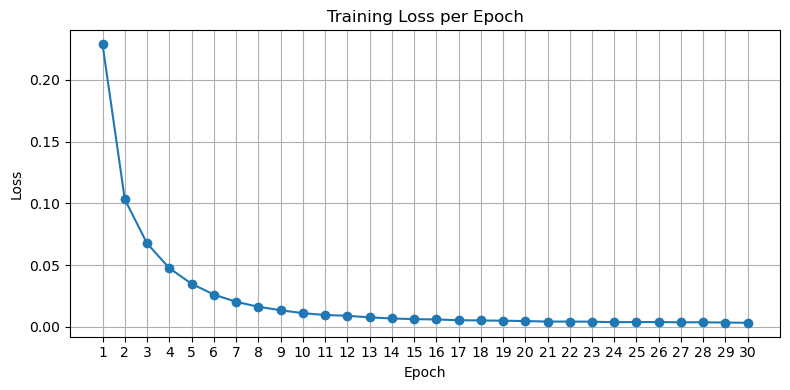

In [61]:
import matplotlib.pyplot as plt

losses = [0.2289, 0.1033, 0.0676, 0.0476, 0.0349, 0.0262, 0.0203, 0.0163, 0.0135, 0.0111, 0.0096, 0.0090, 0.0077, 0.0068, 0.0063, 
          0.0060, 0.0054, 0.0052, 0.0050, 0.0047, 0.0043, 0.0043, 0.0042, 0.0038, 0.0039, 0.0039, 0.0037, 0.0037, 0.0035, 0.0033]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.xticks(range(1, len(losses) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
test_ww['region']=test_ww['region']
test_ww['predicted_tags'] = [
    [i for i in sent] for sent in predictions
]

In [68]:
def map_region(x):
    r1=['sa','nm','mauritius','ghana'] # Africa south
    r2=['kenya','et'] # Africa East
    r3=['eg','alg'] # Africa North
    r4=['af','panaf','afs'] # Africa General
    
    r5=['cosrica','cosric','cuba','elsalv','hond','mex','nic','pan'] # Central America
    r6=['canada','aus','nz'] # Ind. Reg
    
    r7=['oman','jr','israel','iran','uae','saud','qt','kw'] # Middle East

    r8=['in','pk','bangladesh'] # West Asia
    r9=['asia','cn','jp','kr','tw','mong'] # General Asia
    r10=['th','my'] # SEA Asia

    r11=['arg','bol','chile','col','ecuador','guyana','paraguay','peru','uruguay','ven'] # South America

    # Loop through regions, return number of region
    regions = [r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11]
    
    for i, region in enumerate(regions, start=1):
        if x in region:
            return i
        
test_ww['reg']= test_ww['region'].apply(map_region)

In [69]:
regionF1=[]
regionPred=[]
for i in range(1,12):
    evalData=test_ww[test_ww['reg'] == i]
    test_ds = NERDataset(evalData, word2idx)
    test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
    f1_score_val,_,predictions = evaluate_model(model, test_dl, device)
    regionF1.append(f1_score_val)
    regionPred.append(predictions)

In [70]:
regionF1
# [0.4228738400594983,
#  0.273762482923434,
#  0.3745612243128898,
#  0.43511925680852986,
#  0.40944476104648153,
#  0.4212870871469266,
#  0.43283126889419254,
#  0.4528567631850116,
#  0.4303280555492749,
#  0.4547301995795361,
#  0.42718005354246924]

[0.49036749926932693,
 0.37686929628224014,
 0.5234092350980699,
 0.5316209111558114,
 0.441134016585067,
 0.42193097053992945,
 0.4459796711398711,
 0.5187078334341912,
 0.47739528588837715,
 0.4431893402208617,
 0.4643859036605303]

In [72]:
nswitch = [10,100,1000,10000,100000]
switchF1 = []
for i in nswitch:
    train_eng_switched,train_ww_switched=switchTokensNew(train_eng,train_ww,i)
    train_ds = NERDataset(train_eng_switched, word2idx)
    test_ds = NERDataset(test_ww, word2idx)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
    test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

    model = RNN_NER(vocab_size, embedding_dim=embedding_dim, hidden_dim=256, num_classes=num_classes, pretrained_embeddings=embedding_matrix).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=-100) # Ignores padding!
        
    # Train
    train_model(model, train_dl, optimizer, criterion, device, epochs=10)
    
    # Evaluate
    f1_score_val,_,predictions = evaluate_model(model, test_dl, device)
    print(f"F1 Score: {f1_score_val:.4f}, # of switches: {i}")
    switchF1.append(f1_score_val)

100%|██████████| 10/10 [00:00<00:00, 30109.86it/s]


Epoch 1/10 | Loss: 0.2149
Epoch 2/10 | Loss: 0.0899
Epoch 3/10 | Loss: 0.0565
Epoch 4/10 | Loss: 0.0375
Epoch 5/10 | Loss: 0.0269
Epoch 6/10 | Loss: 0.0193
Epoch 7/10 | Loss: 0.0143
Epoch 8/10 | Loss: 0.0107
Epoch 9/10 | Loss: 0.0084
Epoch 10/10 | Loss: 0.0065
F1 Score: 0.3751, # of switches: 10


100%|██████████| 100/100 [00:00<00:00, 51916.13it/s]
c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2157
Epoch 2/10 | Loss: 0.0901
Epoch 3/10 | Loss: 0.0558
Epoch 4/10 | Loss: 0.0375
Epoch 5/10 | Loss: 0.0269
Epoch 6/10 | Loss: 0.0190
Epoch 7/10 | Loss: 0.0143
Epoch 8/10 | Loss: 0.0105
Epoch 9/10 | Loss: 0.0083
Epoch 10/10 | Loss: 0.0067
F1 Score: 0.3637, # of switches: 100


100%|██████████| 1000/1000 [00:00<00:00, 55603.78it/s]
c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2155
Epoch 2/10 | Loss: 0.0904
Epoch 3/10 | Loss: 0.0561
Epoch 4/10 | Loss: 0.0379
Epoch 5/10 | Loss: 0.0263
Epoch 6/10 | Loss: 0.0195
Epoch 7/10 | Loss: 0.0145
Epoch 8/10 | Loss: 0.0106
Epoch 9/10 | Loss: 0.0084
Epoch 10/10 | Loss: 0.0066
F1 Score: 0.4104, # of switches: 1000


100%|██████████| 10000/10000 [00:00<00:00, 56135.95it/s]
c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2210
Epoch 2/10 | Loss: 0.0926
Epoch 3/10 | Loss: 0.0572
Epoch 4/10 | Loss: 0.0384
Epoch 5/10 | Loss: 0.0268
Epoch 6/10 | Loss: 0.0195
Epoch 7/10 | Loss: 0.0145
Epoch 8/10 | Loss: 0.0108
Epoch 9/10 | Loss: 0.0082
Epoch 10/10 | Loss: 0.0069
F1 Score: 0.4564, # of switches: 10000


100%|██████████| 100000/100000 [00:01<00:00, 65202.58it/s]
c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2280
Epoch 2/10 | Loss: 0.1003
Epoch 3/10 | Loss: 0.0624
Epoch 4/10 | Loss: 0.0416
Epoch 5/10 | Loss: 0.0287
Epoch 6/10 | Loss: 0.0203
Epoch 7/10 | Loss: 0.0149
Epoch 8/10 | Loss: 0.0113
Epoch 9/10 | Loss: 0.0088
Epoch 10/10 | Loss: 0.0069
F1 Score: 0.4863, # of switches: 100000


In [73]:
switchF1
# [0.3230788908329926,
#  0.3382171898034997,
#  0.3460795852475261,
#  0.4035641015919964,
#  0.43577411470705646]

[0.3750998528471229,
 0.36365806505280446,
 0.41038421429893984,
 0.45642613426139694,
 0.486331044523439]

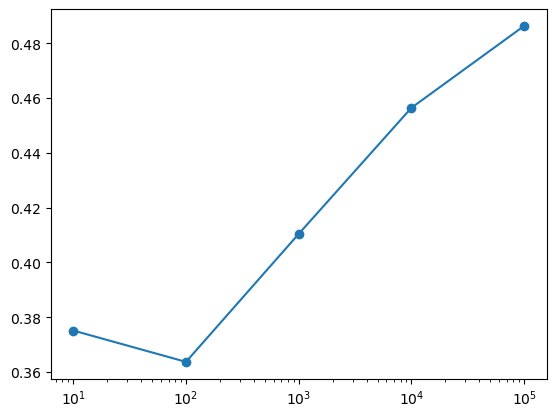

In [74]:
import matplotlib.pyplot as plt
x=[10,100,1000,10000,100000]
y=[0.3750998528471229,
 0.36365806505280446,
 0.41038421429893984,
 0.45642613426139694,
 0.486331044523439]
plt.plot(x,y)
plt.scatter(x,y)
plt.xscale('log')

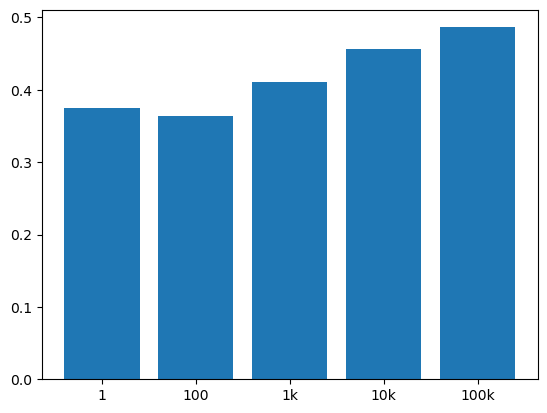

In [75]:
x_labels = ['1', '100', '1k', '10k', '100k']
x_pos = range(len(x_labels))
plt.bar(x_pos, y)
plt.xticks(x_pos, x_labels)
plt.show()

In [80]:
## Experiment matrix
###### NOTE: Make sure you have the right amount of swaps!!!! Defaults to 100k, that has had best performance so far
experiments = [
    {"name": "Train: English | Test: English", "train": train_eng, "test": test_eng},
    {"name": "Train: Global   | Test: Global", "train": train_ww, "test": test_ww},
    {"name": "Train: Combined | Test: Global",   "train": train_combined,  "test": test_ww},
    {"name": "Train: Swapped Combined | Test: Global",   "train": train_combined_switched,  "test": test_ww},
    {"name": "Train: English   | Test: Global",   "train": train_eng, "test": test_ww},
    {"name": "Train: Swapped English   | Test: Global",   "train": train_eng_switched, "test": test_ww},
]
results = {}

for exp in experiments:
    print(f"\n{'='*50}\nRunning: {exp['name']}\n{'='*50}")
    
    # Create DataLoaders
    train_ds = NERDataset(exp["train"], word2idx)
    test_ds = NERDataset(exp["test"], word2idx)
    
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
    test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
    
    # Initialize a fresh model for each experiment
    model = RNN_NER(vocab_size, embedding_dim=embedding_dim, hidden_dim=256, num_classes=num_classes, pretrained_embeddings=embedding_matrix).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=-100) # Ignores padding!
    
    # Train
    train_model(model, train_dl, optimizer, criterion, device, epochs=10)
    
    # Evaluate
    f1_score_val,_,predictions = evaluate_model(model, test_dl, device)
    print(f"F1 Score: {f1_score_val:.4f}")

# Final Summary
print("\n--- Final Experiment Results (F1 Score) ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")


Running: Train: English | Test: English
Epoch 1/10 | Loss: 0.2180
Epoch 2/10 | Loss: 0.0904
Epoch 3/10 | Loss: 0.0560
Epoch 4/10 | Loss: 0.0377
Epoch 5/10 | Loss: 0.0262
Epoch 6/10 | Loss: 0.0190
Epoch 7/10 | Loss: 0.0139
Epoch 8/10 | Loss: 0.0106
Epoch 9/10 | Loss: 0.0082
Epoch 10/10 | Loss: 0.0066
F1 Score: 0.7187

Running: Train: Global   | Test: Global


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.3261
Epoch 2/10 | Loss: 0.0956
Epoch 3/10 | Loss: 0.0472
Epoch 4/10 | Loss: 0.0266
Epoch 5/10 | Loss: 0.0164
Epoch 6/10 | Loss: 0.0114
Epoch 7/10 | Loss: 0.0087
Epoch 8/10 | Loss: 0.0060
Epoch 9/10 | Loss: 0.0050
Epoch 10/10 | Loss: 0.0040
F1 Score: 0.7218

Running: Train: Combined | Test: Global


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2125
Epoch 2/10 | Loss: 0.0951
Epoch 3/10 | Loss: 0.0587
Epoch 4/10 | Loss: 0.0387
Epoch 5/10 | Loss: 0.0265
Epoch 6/10 | Loss: 0.0192
Epoch 7/10 | Loss: 0.0139
Epoch 8/10 | Loss: 0.0108
Epoch 9/10 | Loss: 0.0086
Epoch 10/10 | Loss: 0.0072
F1 Score: 0.9347

Running: Train: Swapped Combined | Test: Global


...

Epoch 1/10 | Loss: 0.2139
Epoch 2/10 | Loss: 0.1006
Epoch 3/10 | Loss: 0.0649
Epoch 4/10 | Loss: 0.0436
Epoch 5/10 | Loss: 0.0304
Epoch 6/10 | Loss: 0.0214
Epoch 7/10 | Loss: 0.0158
Epoch 8/10 | Loss: 0.0118
Epoch 9/10 | Loss: 0.0093
Epoch 10/10 | Loss: 0.0075
F1 Score: 0.6383

Running: Train: English   | Test: Global


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2162
Epoch 2/10 | Loss: 0.0897
Epoch 3/10 | Loss: 0.0553
Epoch 4/10 | Loss: 0.0377
Epoch 5/10 | Loss: 0.0263
Epoch 6/10 | Loss: 0.0190
Epoch 7/10 | Loss: 0.0142
Epoch 8/10 | Loss: 0.0106
Epoch 9/10 | Loss: 0.0084
Epoch 10/10 | Loss: 0.0064
F1 Score: 0.3674

Running: Train: Swapped English   | Test: Global


c:\Users\anna-\anaconda3\envs\ml\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1/10 | Loss: 0.2244
Epoch 2/10 | Loss: 0.1000
Epoch 3/10 | Loss: 0.0621
Epoch 4/10 | Loss: 0.0415
Epoch 5/10 | Loss: 0.0283
Epoch 6/10 | Loss: 0.0206
Epoch 7/10 | Loss: 0.0142
Epoch 8/10 | Loss: 0.0113
Epoch 9/10 | Loss: 0.0090
Epoch 10/10 | Loss: 0.0070
F1 Score: 0.4806

--- Final Experiment Results (F1 Score) ---
